In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from epiweeks import Week
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# ----------------------------- CONFIG -----------------------------
PARQUET  = "../data/processed/dataset_tft_completo.parquet"   # ajuste se rodar de outro diretório
SUB_DIR  = "../src/outputs/submissions"                        # saída do build_submissions.py
REPORTS  = "../reports"                                        # figuras/tabelas exportadas
os.makedirs(os.path.join(REPORTS, "images"), exist_ok=True)

TESTS = [(1, 2022), (2, 2023), (3, 2024), (4, 2025)]  # (id do teste, ano inicial da temporada)

INTERVAL_ORDER = ["lower_95","lower_90","lower_80","lower_50","pred",
                  "upper_50","upper_80","upper_90","upper_95"]
ALPHAS = {0.50:("lower_50","upper_50"), 0.20:("lower_80","upper_80"),
          0.10:("lower_90","upper_90"), 0.05:("lower_95","upper_95")}
NOMINAL = {0.50:0.50, 0.20:0.80, 0.10:0.90, 0.05:0.95}  # alpha -> cobertura nominal

DENGUE_CITIES = {
    "2931350":"Teixeira de Freitas-BA","2933307":"Vitoria da Conquista-BA",
    "2302503":"Brejo Santo-CE","3119401":"Coronel Fabriciano-MG",
    "3549805":"Sao Jose do Rio Preto-SP","3541406":"Presidente Prudente-SP",
    "1200401":"Rio Branco-AC","1200203":"Cruzeiro do Sul-AC",
    "1716109":"Paraiso do Tocantins-TO","4113700":"Londrina-PR",
    "4103701":"Cambe-PR","4104808":"Cascavel-PR",
    "5201405":"Aparecida de Goiania-GO","5102637":"Campo Novo do Parecis-MT",
    "5215231":"Novo Gama-GO",
}
UF_CODE = {"11":"RO","12":"AC","13":"AM","14":"RR","15":"PA","16":"AP","17":"TO",
           "21":"MA","22":"PI","23":"CE","24":"RN","25":"PB","26":"PE","27":"AL","28":"SE","29":"BA",
           "31":"MG","32":"ES","33":"RJ","35":"SP","41":"PR","42":"SC","43":"RS",
           "50":"MS","51":"MT","52":"GO","53":"DF"}
EXCLUDE_UF = "ES"

def season_sundays(start_year):
    w, end = Week(start_year, 41, system="cdc"), Week(start_year+1, 40, system="cdc")
    d = []
    while w <= end:
        d.append(pd.Timestamp(w.startdate())); w = w + 1
    return d

def to_ew_sunday(dates):
    # domingo (início da semana MMWR) da data -> alinha observado e previsto
    s = pd.to_datetime(dates)
    return s - pd.to_timedelta((s.dt.weekday + 1) % 7, unit="D")

def ew_of(date):
    return Week.fromdate(pd.Timestamp(date).date(), system="cdc").week


## 1. Dados observados

Lemos `casos` do parquet, alinhamos cada registro ao **domingo da sua semana
epidemiológica** e montamos duas verdades: por cidade (as 15) e por UF (soma dos
municípios, exceto ES).

In [2]:
usecols = ["geocode", "date", "casos"]
obs_raw = pd.read_parquet(PARQUET, columns=usecols)
obs_raw["geocode"] = obs_raw["geocode"].astype(str).str.zfill(7)
obs_raw["casos"] = pd.to_numeric(obs_raw["casos"], errors="coerce").fillna(0.0)
obs_raw["sunday"] = to_ew_sunday(obs_raw["date"])

# cidade: casos por geocode/semana
obs_city = (obs_raw[obs_raw.geocode.isin(DENGUE_CITIES)]
            .groupby(["geocode","sunday"], as_index=False)["casos"].sum())

# estado: soma municipios por UF (exceto ES)
obs_raw["uf"] = obs_raw["geocode"].str[:2].map(UF_CODE)
obs_state = (obs_raw[obs_raw.uf.notna() & (obs_raw.uf != EXCLUDE_UF)]
             .groupby(["uf","sunday"], as_index=False)["casos"].sum())

print("observado cidade:", obs_city.geocode.nunique(), "cidades |",
      "estado:", obs_state.uf.nunique(), "UFs")

def get_observed(level, unit):
    if level == "city":
        d = obs_city[obs_city.geocode == unit][["sunday","casos"]]
    else:
        d = obs_state[obs_state.uf == unit][["sunday","casos"]]
    return d.rename(columns={"sunday":"date","casos":"obs"})


observado cidade: 15 cidades | estado: 26 UFs


## 2. Previsões + alinhamento

Carregamos os CSVs por unidade e montamos um **painel** com uma linha por
(nível, unidade, teste, semana), já unindo observado e previsto pela data da semana.
Semanas sem observado (futuro da 2025‑26) são descartadas do cálculo, mas contabilizadas
como cobertura da temporada.

In [3]:
def load_pred(level, unit, test):
    sub = "dengue_city" if level == "city" else "dengue_state"
    year = dict(TESTS)[test]
    path = os.path.join(SUB_DIR, sub, f"test{test}_{year}", f"{unit}.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df

rows = []
missing = []
for test, year in TESTS:
    sundays = season_sundays(year)
    idx_of = {d:i for i,d in enumerate(sundays)}
    units = [("city",g) for g in DENGUE_CITIES] + \
            [("state",uf) for uf in sorted(set(UF_CODE.values())) if uf != EXCLUDE_UF]
    for level, unit in units:
        pred = load_pred(level, unit, test)
        if pred is None:
            missing.append((level, unit, test)); continue
        obs = get_observed(level, unit)
        m = pred.merge(obs, on="date", how="left")
        m["level"], m["unit"], m["test"], m["season"] = level, unit, test, f"{year}-{year+1}"
        m["week_idx"] = m["date"].map(idx_of)
        m["ew"] = m["date"].map(ew_of)
        rows.append(m)

panel = pd.concat(rows, ignore_index=True)
panel_obs = panel.dropna(subset=["obs"]).copy()   # apenas semanas com observado
print(f"linhas totais: {len(panel)} | com observado: {len(panel_obs)}")
if missing:
    print(f"\n⚠️ {len(missing)} unidade(s)-teste sem CSV de previsão (ex.: {missing[:5]})")
    print("   -> se forem cidades sem ajuste do episcanner numa temporada, precisam de fallback.")


linhas totais: 8569 | com observado: 6929


## 3. Métricas

**WIS** (por semana, média na temporada). Decomposição:
- **dispersão** = largura dos intervalos (nitidez); alta demais = intervalos largos.
- **sub‑previsão** = penalidade quando o observado fica *acima* do previsto.
- **super‑previsão** = penalidade quando o observado fica *abaixo*.
Se sub ≫ super, o modelo subestima sistematicamente (e vice‑versa).

**Cobertura**: fração de semanas em que o observado caiu dentro de cada intervalo. Deve
bater com o nominal (50/80/95/95%). Cobertura **abaixo** do nominal = intervalos
**estreitos demais** (excesso de confiança) — costuma ser o caso quando a incerteza é
propagada de forma independente.

**Pico**: erro em semanas entre o pico previsto e o observado, e razão de magnitude.
**Total**: razão entre soma prevista e observada na temporada.

Versões **escaladas** (`_scaled` = métrica / média do observado) tornam as unidades
comparáveis entre si.

In [4]:
def _is(y, l, u, a):
    return (u - l) + (2/a)*np.maximum(l - y, 0) + (2/a)*np.maximum(y - u, 0)

def wis_parts(y, df):
    y = np.asarray(y, float); K = len(ALPHAS)
    m = df["pred"].to_numpy(float)
    disp = np.zeros_like(y); under = 0.5*np.maximum(y-m,0); over = 0.5*np.maximum(m-y,0)
    for a,(lo,hi) in ALPHAS.items():
        l = df[lo].to_numpy(float); u = df[hi].to_numpy(float)
        disp  += (a/2)*(u-l)
        under += np.maximum(y-u, 0)
        over  += np.maximum(l-y, 0)
    Z = K + 0.5
    return (disp+under+over)/Z, disp/Z, under/Z, over/Z

def metrics_for(g):
    y = g["obs"].to_numpy(float); m = g["pred"].to_numpy(float)
    w, disp, under, over = wis_parts(y, g)
    mean_obs = max(y.mean(), 1e-9)
    cov = {f"cov_{int(NOMINAL[a]*100)}": float(((g[lo]<=y)&(y<=g[hi])).mean())
           for a,(lo,hi) in ALPHAS.items()}
    # pico
    ip_o, ip_p = int(np.argmax(y)), int(np.argmax(m))
    out = dict(
        n_weeks=len(g), season_weeks=int(g["week_idx"].max())+1 if len(g) else 0,
        wis=float(w.mean()), disp=float(disp.mean()),
        under=float(under.mean()), over=float(over.mean()),
        wis_scaled=float(w.mean()/mean_obs),
        mae=float(np.mean(np.abs(m-y))), rmse=float(np.sqrt(np.mean((m-y)**2))),
        mae_scaled=float(np.mean(np.abs(m-y))/mean_obs),
        bias=float(np.mean(m-y)),
        peak_ew_obs=int(g["ew"].iloc[ip_o]), peak_ew_pred=int(g["ew"].iloc[ip_p]),
        peak_week_err=int(ip_p-ip_o),
        peak_obs=float(y[ip_o]), peak_pred=float(m[ip_p]),
        peak_ratio=float(m[ip_p]/max(y[ip_o],1e-9)),
        total_obs=float(y.sum()), total_pred=float(m.sum()),
        total_ratio=float(m.sum()/max(y.sum(),1e-9)),
    )
    out.update(cov)
    return pd.Series(out)

M = (panel_obs.groupby(["level","unit","test","season"])
     .apply(metrics_for).reset_index())
M["name"] = M.apply(lambda r: DENGUE_CITIES.get(r["unit"], r["unit"]), axis=1)
print(M.shape)
M.head()


(164, 29)


,level,unit,test,season,n_weeks,season_weeks,wis,disp,under,over,...,peak_pred,peak_ratio,total_obs,total_pred,total_ratio,cov_50,cov_80,cov_90,cov_95,name
0,city,1200203,1,2022-2023,52.0,52.0,25.170638,11.357331,13.788877,0.024430,...,37.147843,0.168854,3788.0,841.380800,0.222117,0.461538,0.730769,0.923077,0.942308,Cruzeiro do Sul-AC
1,city,1200203,2,2023-2024,52.0,52.0,91.264943,11.357713,79.891211,0.016019,...,37.152934,0.058051,9673.0,841.475535,0.086992,0.134615,0.500000,0.596154,0.653846,Cruzeiro do Sul-AC
2,city,1200203,3,2024-2025,52.0,52.0,519.686653,11.358372,508.328282,0.000000,...,37.153780,0.016888,34740.0,841.478932,0.024222,0.000000,0.019231,0.173077,0.230769,Cruzeiro do Sul-AC
3,city,1200203,4,2025-2026,13.0,13.0,69.409570,5.743268,63.666302,0.000000,...,13.787083,0.059944,1902.0,105.711065,0.055579,0.000000,0.000000,0.230769,0.692308,Cruzeiro do Sul-AC
4,city,1200401,1,2022-2023,52.0,52.0,26.910052,14.572052,12.239162,0.098838,...,48.013701,0.179156,4018.0,890.573266,0.221646,0.442308,0.826923,0.846154,0.846154,Rio Branco-AC


## 4. Onde é bom / onde é ruim (resumos)

Primeiro o panorama por trilha e temporada, depois os *rankings* de melhores e piores
unidades (por WIS escalado, que compara entre unidades).

In [5]:
# panorama por trilha x temporada (WIS médio e escalado)
pivot_wis = M.pivot_table(index="level", columns="season", values="wis", aggfunc="mean").round(1)
pivot_scl = M.pivot_table(index="level", columns="season", values="wis_scaled", aggfunc="mean").round(3)
print("WIS médio por trilha x temporada:\n", pivot_wis, "\n")
print("WIS ESCALADO (WIS/casos) por trilha x temporada — comparável:\n", pivot_scl)


WIS médio por trilha x temporada:
 season  2022-2023  2023-2024  2024-2025  2025-2026
level                                             
city       1052.5     1679.6     1312.9      248.7
state      4470.6    24132.2     5331.2     1080.4 

WIS ESCALADO (WIS/casos) por trilha x temporada — comparável:
 season  2022-2023  2023-2024  2024-2025  2025-2026
level                                             
city        0.597      0.726      0.602      0.590
state       0.579      0.762      0.527      0.583


In [6]:
# ranking: média do WIS escalado por unidade (sobre as temporadas)
rank = (M.groupby(["level","unit","name"])
        .agg(wis_scaled=("wis_scaled","mean"), wis=("wis","mean"),
             total_obs=("total_obs","sum")).reset_index()
        .sort_values("wis_scaled"))
for level in ["state","city"]:
    r = rank[rank.level==level]
    print(f"\n=== {level.upper()} — melhores (WIS escalado) ===")
    print(r.head(5)[["name","wis_scaled","wis"]].to_string(index=False))
    print(f"=== {level.upper()} — piores ===")
    print(r.tail(5)[["name","wis_scaled","wis"]].to_string(index=False))



=== STATE — melhores (WIS escalado) ===
name  wis_scaled          wis
  CE    0.347748   336.378176
  TO    0.419529   157.754385
  MS    0.455804  1297.067828
  GO    0.484389 10429.385691
  AM    0.513728   352.103613
=== STATE — piores ===
name  wis_scaled          wis
  MG    0.706830 61501.991489
  BA    0.742414  8634.203829
  PA    0.763990   934.199865
  MT    0.780773  2994.855202
  SP    0.783141 83595.916700

=== CITY — melhores (WIS escalado) ===
                    name  wis_scaled        wis
Campo Novo do Parecis-MT    0.416307   9.081435
      Cruzeiro do Sul-AC    0.522111 176.382951
 Aparecida de Goiania-GO    0.523190 839.240879
            Novo Gama-GO    0.556705 315.931980
   Coronel Fabriciano-MG    0.580591 244.312387
=== CITY — piores ===
                   name  wis_scaled         wis
         Brejo Santo-CE    0.696163  113.219395
 Teixeira de Freitas-BA    0.726332  314.130843
 Presidente Prudente-SP    0.748937 2623.790748
Vitoria da Conquista-BA    0.77022

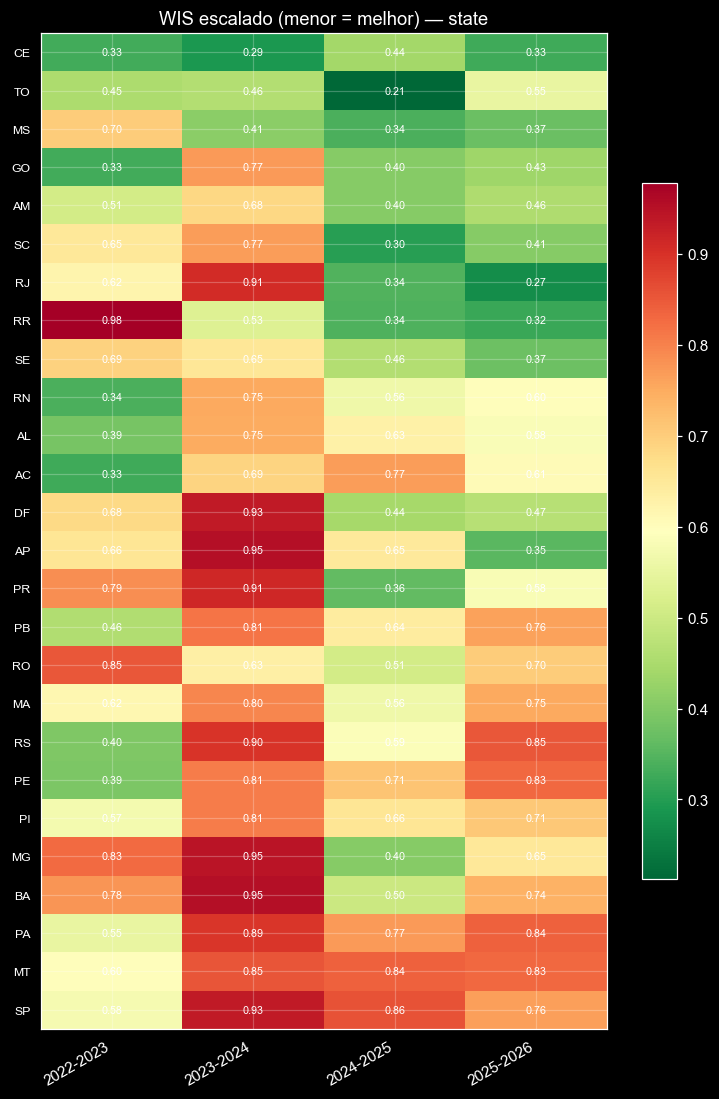

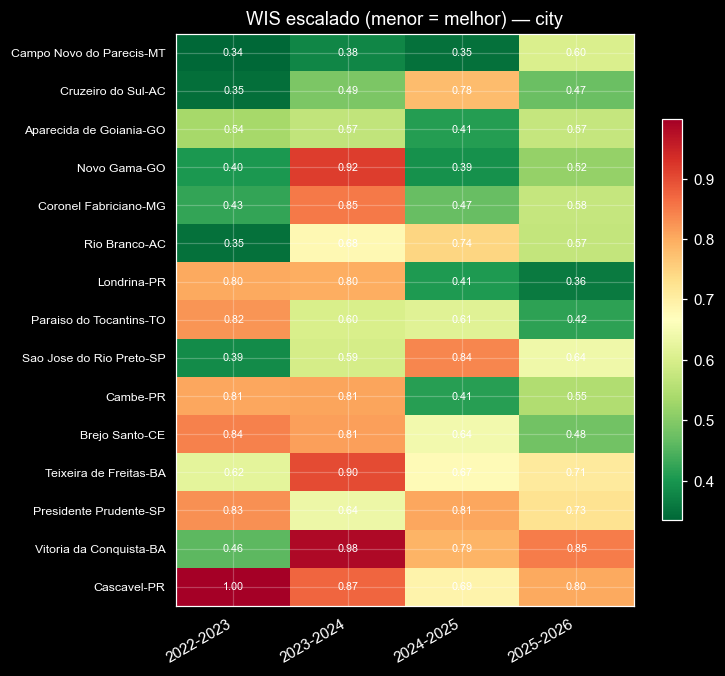

In [7]:
# heatmap unidade x temporada (WIS escalado) — enxerga padrões espaço-temporais
def heatmap(level):
    sub = M[M.level==level].pivot_table(index="unit", columns="season",
                                        values="wis_scaled", aggfunc="mean")
    sub = sub.reindex(sub.mean(axis=1).sort_values().index)  # ordena por desempenho
    labels = [DENGUE_CITIES.get(u,u) for u in sub.index]
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35*len(sub)+1)))
    im = ax.imshow(sub.values, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(sub.columns, rotation=30, ha="right")
    ax.set_yticks(range(sub.shape[0])); ax.set_yticklabels(labels, fontsize=8)
    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            v = sub.values[i,j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"WIS escalado (menor = melhor) — {level}")
    fig.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

heatmap("state")
heatmap("city")


## 5. Calibração e viés sistemático

A **cobertura** empírica vs. nominal diz se os intervalos são confiáveis. Abaixo da
diagonal = estreitos demais. A **decomposição do WIS** empilhada mostra se o erro vem de
intervalos largos (dispersão) ou de viés (sub/super‑previsão).

Cobertura (todas as semanas):
  nominal  empirica
    0.50     0.084
    0.80     0.192
    0.90     0.291
    0.95     0.353


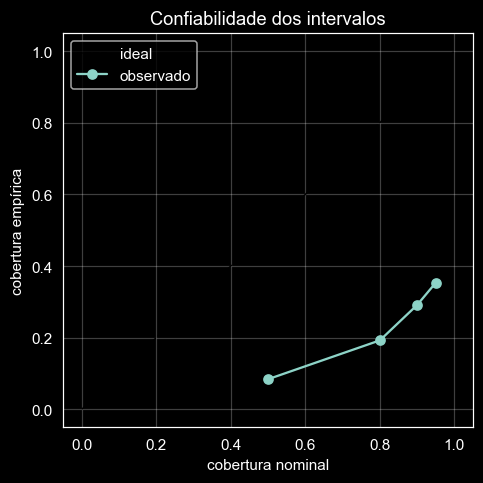

In [8]:
# cobertura empírica agregada (ponderada por semanas)
cov_cols = [f"cov_{int(NOMINAL[a]*100)}" for a in ALPHAS]
w = panel_obs.assign(one=1)
emp = {}
for a,(lo,hi) in ALPHAS.items():
    inside = ((panel_obs[lo] <= panel_obs["obs"]) & (panel_obs["obs"] <= panel_obs[hi]))
    emp[NOMINAL[a]] = inside.mean()
cov_tab = pd.DataFrame({"nominal":list(emp.keys()), "empirica":list(emp.values())}).sort_values("nominal")
print("Cobertura (todas as semanas):\n", cov_tab.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(4.5,4.5))
ax.plot([0,1],[0,1],"k--",lw=1,label="ideal")
ax.plot(cov_tab["nominal"], cov_tab["empirica"], "o-", label="observado")
ax.set_xlabel("cobertura nominal"); ax.set_ylabel("cobertura empírica")
ax.set_title("Confiabilidade dos intervalos"); ax.legend(); plt.tight_layout(); plt.show()


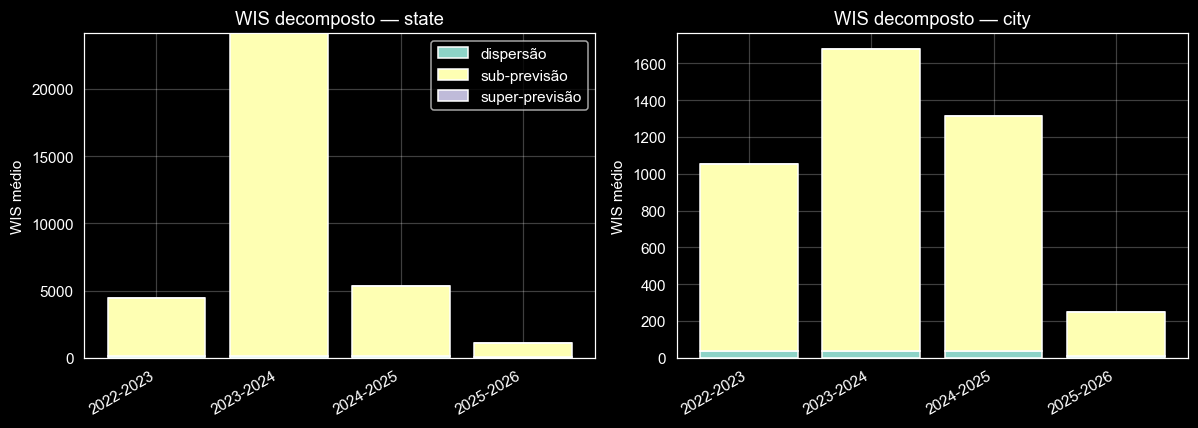

In [9]:
# decomposição do WIS empilhada, por trilha x temporada
agg = M.groupby(["level","season"])[["disp","under","over"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=False)
for ax, level in zip(axes, ["state","city"]):
    a = agg[agg.level==level]
    x = np.arange(len(a))
    ax.bar(x, a["disp"], label="dispersão")
    ax.bar(x, a["under"], bottom=a["disp"], label="sub-previsão")
    ax.bar(x, a["over"], bottom=a["disp"]+a["under"], label="super-previsão")
    ax.set_xticks(x); ax.set_xticklabels(a["season"], rotation=30, ha="right")
    ax.set_title(f"WIS decomposto — {level}"); ax.set_ylabel("WIS médio")
axes[0].legend(); plt.tight_layout(); plt.show()


## 6. Visualização central: *fan charts*

Observado (pontos) vs. mediana (linha) com as faixas de 50/80/90/95%. É a forma mais
direta de ver se a curva prevista acompanha o surto e se os intervalos cobrem o observado.

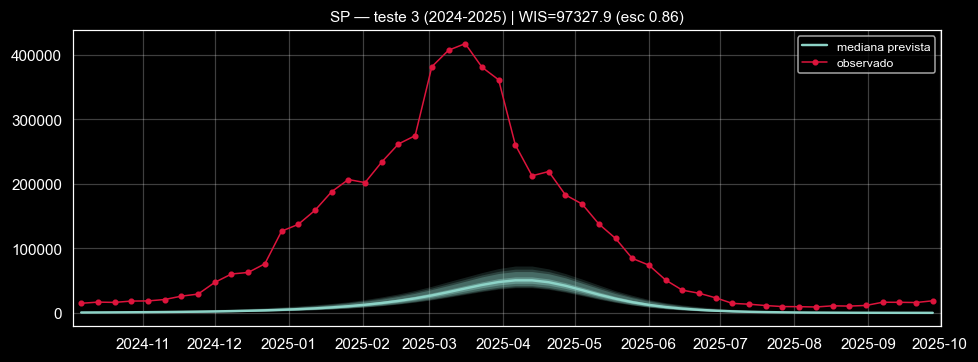

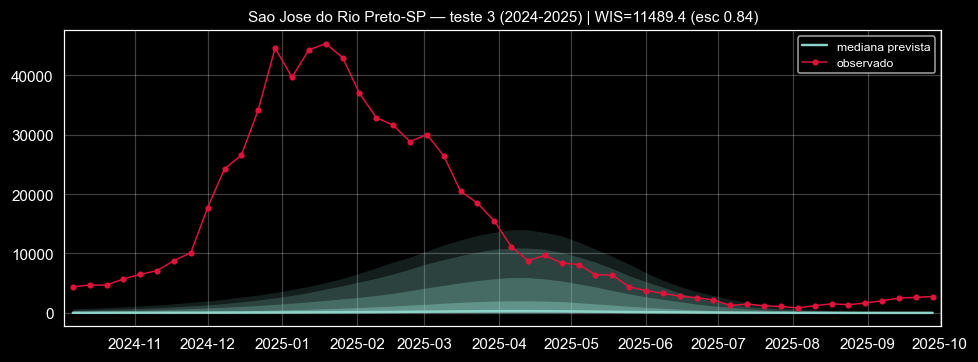

In [10]:
BANDS = [("lower_95","upper_95",0.15),("lower_90","upper_90",0.20),
         ("lower_80","upper_80",0.28),("lower_50","upper_50",0.40)]

def fan_chart(level, unit, test, ax=None):
    g = panel[(panel.level==level)&(panel.unit==unit)&(panel.test==test)].sort_values("date")
    if g.empty:
        print(f"sem dados: {level} {unit} teste {test}"); return
    if ax is None:
        fig, ax = plt.subplots(figsize=(9,3.4))
    for lo,hi,al in BANDS:
        ax.fill_between(g["date"], g[lo], g[hi], color="C0", alpha=al, lw=0)
    ax.plot(g["date"], g["pred"], color="C0", lw=1.6, label="mediana prevista")
    go = g.dropna(subset=["obs"])
    ax.plot(go["date"], go["obs"], "o-", color="crimson", ms=3, lw=1, label="observado")
    row = M[(M.level==level)&(M.unit==unit)&(M.test==test)]
    wtxt = f" | WIS={row['wis'].iloc[0]:.1f} (esc {row['wis_scaled'].iloc[0]:.2f})" if len(row) else ""
    name = DENGUE_CITIES.get(unit, unit)
    ax.set_title(f"{name} — teste {test} ({dict(TESTS)[test]}-{dict(TESTS)[test]+1}){wtxt}", fontsize=10)
    ax.legend(fontsize=8); ax.margins(x=0.01)
    return ax

# exemplos
fan_chart("state", "SP", 3); plt.tight_layout(); plt.show()
fan_chart("city", "3549805", 3); plt.tight_layout(); plt.show()


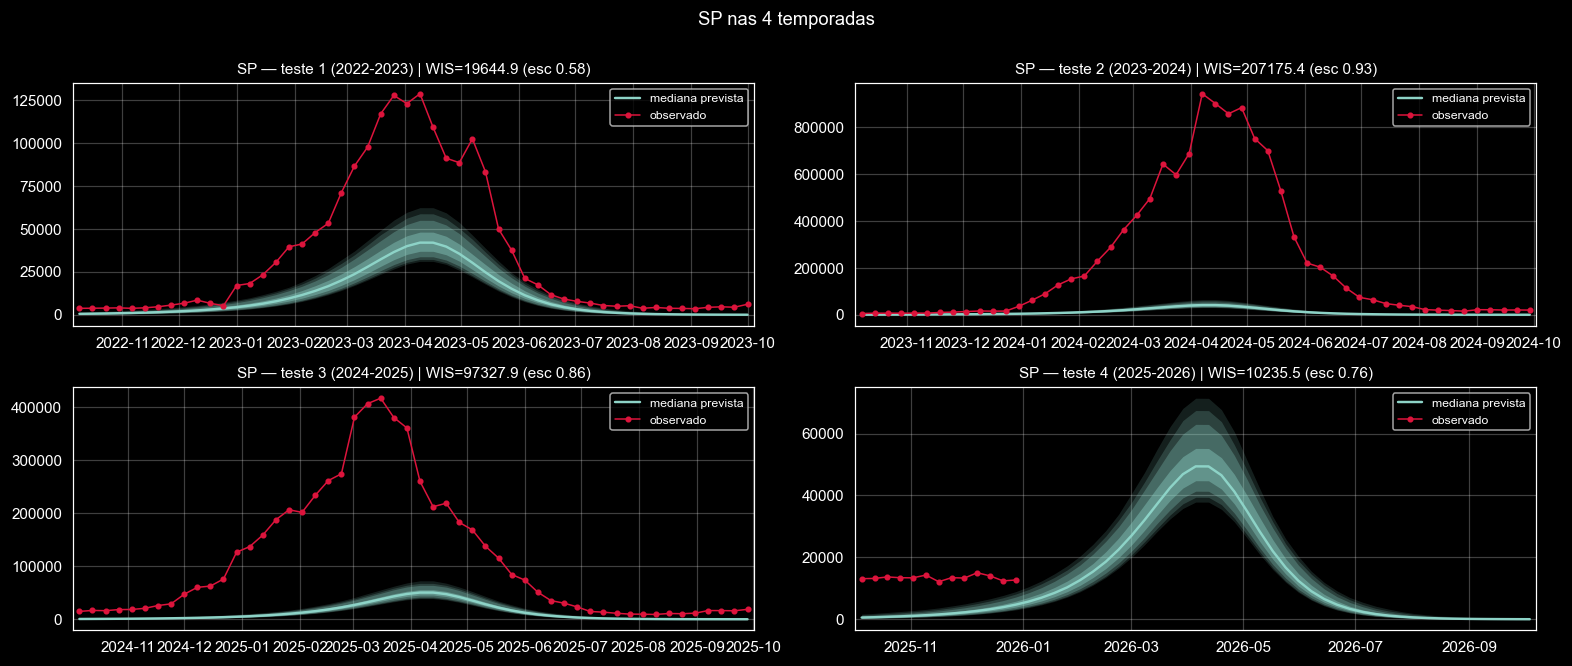

In [11]:
def fan_grid(items, ncols=2, title=None):
    n = len(items); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2*ncols, 3.0*nrows), squeeze=False)
    for ax, (lv,un,ts) in zip(axes.flat, items):
        fan_chart(lv, un, ts, ax=ax)
    for ax in axes.flat[n:]:
        ax.axis("off")
    if title: fig.suptitle(title, y=1.001, fontsize=12)
    plt.tight_layout(); plt.show()

# uma UF nas 4 temporadas (evolução do desempenho)
fan_grid([("state","SP",t) for t,_ in TESTS], ncols=2, title="SP nas 4 temporadas")


## 7. Diagnósticos entre unidades

Onde erra mais em função da magnitude, calibração da mediana, crescimento do erro ao
longo da temporada e acerto do pico.

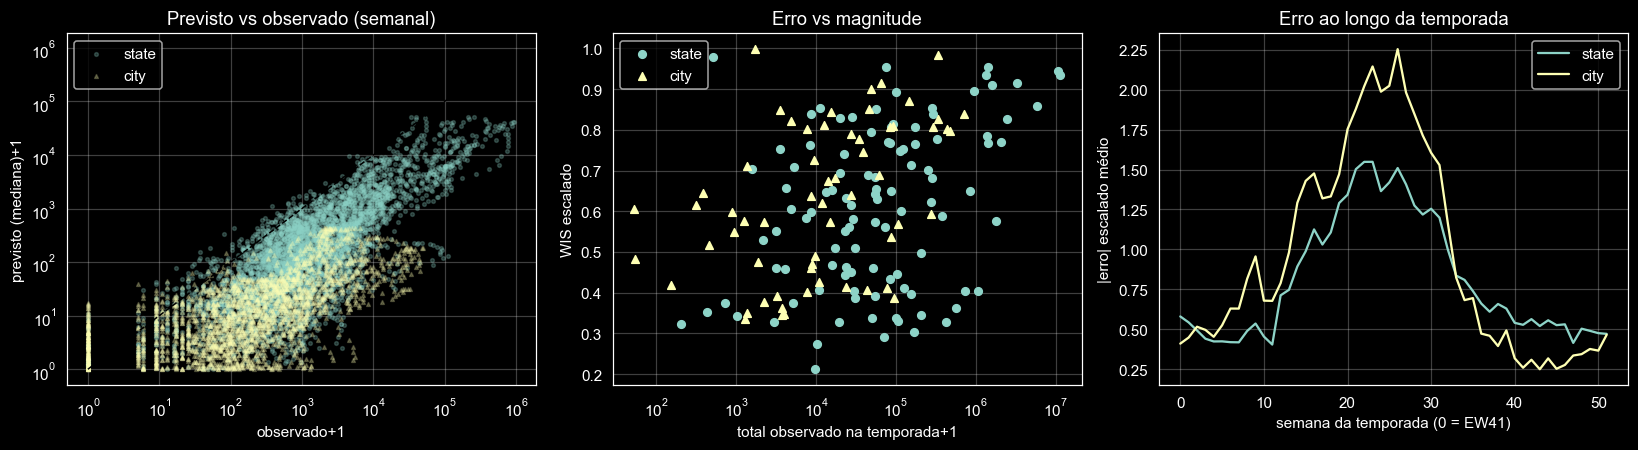

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2))

# (a) previsto vs observado (log-log), por semana
ax = axes[0]
for lv,mk,cl in [("state","o","C0"),("city","^","C1")]:
    d = panel_obs[panel_obs.level==lv]
    ax.scatter(d["obs"]+1, d["pred"]+1, s=6, alpha=0.25, marker=mk, color=cl, label=lv)
lim = [1, max(panel_obs["obs"].max(), panel_obs["pred"].max())+1]
ax.plot(lim, lim, "k--", lw=1); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("observado+1"); ax.set_ylabel("previsto (mediana)+1")
ax.set_title("Previsto vs observado (semanal)"); ax.legend()

# (b) erro (WIS escalado) vs magnitude do surto
ax = axes[1]
for lv,mk,cl in [("state","o","C0"),("city","^","C1")]:
    d = M[M.level==lv]
    ax.scatter(d["total_obs"]+1, d["wis_scaled"], s=25, marker=mk, color=cl, label=lv)
ax.set_xscale("log"); ax.set_xlabel("total observado na temporada+1")
ax.set_ylabel("WIS escalado"); ax.set_title("Erro vs magnitude"); ax.legend()

# (c) MAE por semana da temporada (horizonte)
ax = axes[2]
for lv,cl in [("state","C0"),("city","C1")]:
    d = panel_obs[panel_obs.level==lv].copy()
    d["ae"] = (d["pred"]-d["obs"]).abs()
    d["ae_scaled"] = d["ae"] / d.groupby(["unit","test"])["obs"].transform("mean").clip(lower=1e-9)
    prof = d.groupby("week_idx")["ae_scaled"].mean()
    ax.plot(prof.index, prof.values, label=lv, color=cl)
ax.set_xlabel("semana da temporada (0 = EW41)"); ax.set_ylabel("|erro| escalado médio")
ax.set_title("Erro ao longo da temporada"); ax.legend()
plt.tight_layout(); plt.show()


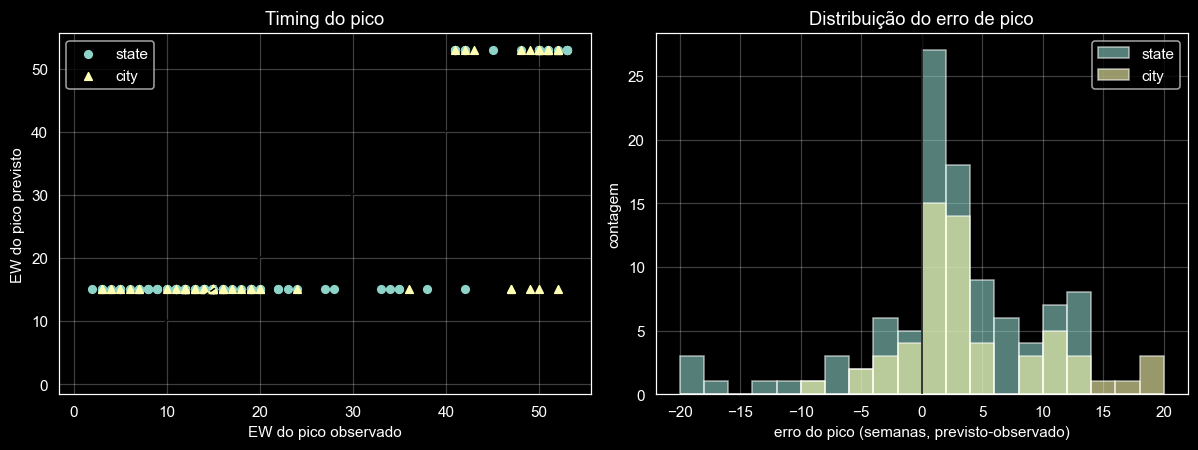

In [13]:
# acerto do pico: previsto vs observado + histograma do erro em semanas
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
ax = axes[0]
for lv,mk,cl in [("state","o","C0"),("city","^","C1")]:
    d = M[M.level==lv]
    ax.scatter(d["peak_ew_obs"], d["peak_ew_pred"], s=25, marker=mk, color=cl, label=lv)
ax.plot([1,52],[1,52],"k--",lw=1); ax.set_xlabel("EW do pico observado")
ax.set_ylabel("EW do pico previsto"); ax.set_title("Timing do pico"); ax.legend()
ax = axes[1]
ax.hist(M[M.level=="state"]["peak_week_err"], bins=range(-20,21,2), alpha=0.6, label="state")
ax.hist(M[M.level=="city"]["peak_week_err"], bins=range(-20,21,2), alpha=0.6, label="city")
ax.axvline(0, color="k", lw=1); ax.set_xlabel("erro do pico (semanas, previsto-observado)")
ax.set_ylabel("contagem"); ax.set_title("Distribuição do erro de pico"); ax.legend()
plt.tight_layout(); plt.show()


## 8. Casos interessantes (seleção automática)

Selecionamos automaticamente exemplos que valem inspeção: melhor e pior WIS, maior erro de
pico, pior calibração (cobertura de 95% muito abaixo do nominal), maior sub e maior
super‑previsão, e o maior surto. Cada um vira um *fan chart*.

- melhor WIS escalado     : state TO (teste 3)
- pior WIS escalado       : city  Cascavel-PR (teste 1)
- maior erro de pico      : state AL (teste 1)
- pior cobertura 95%      : city  Vitoria da Conquista-BA (teste 4)
- maior sub-previsão      : state SP (teste 2)
- maior super-previsão    : state MG (teste 3)
- maior surto (total obs) : state SP (teste 2)


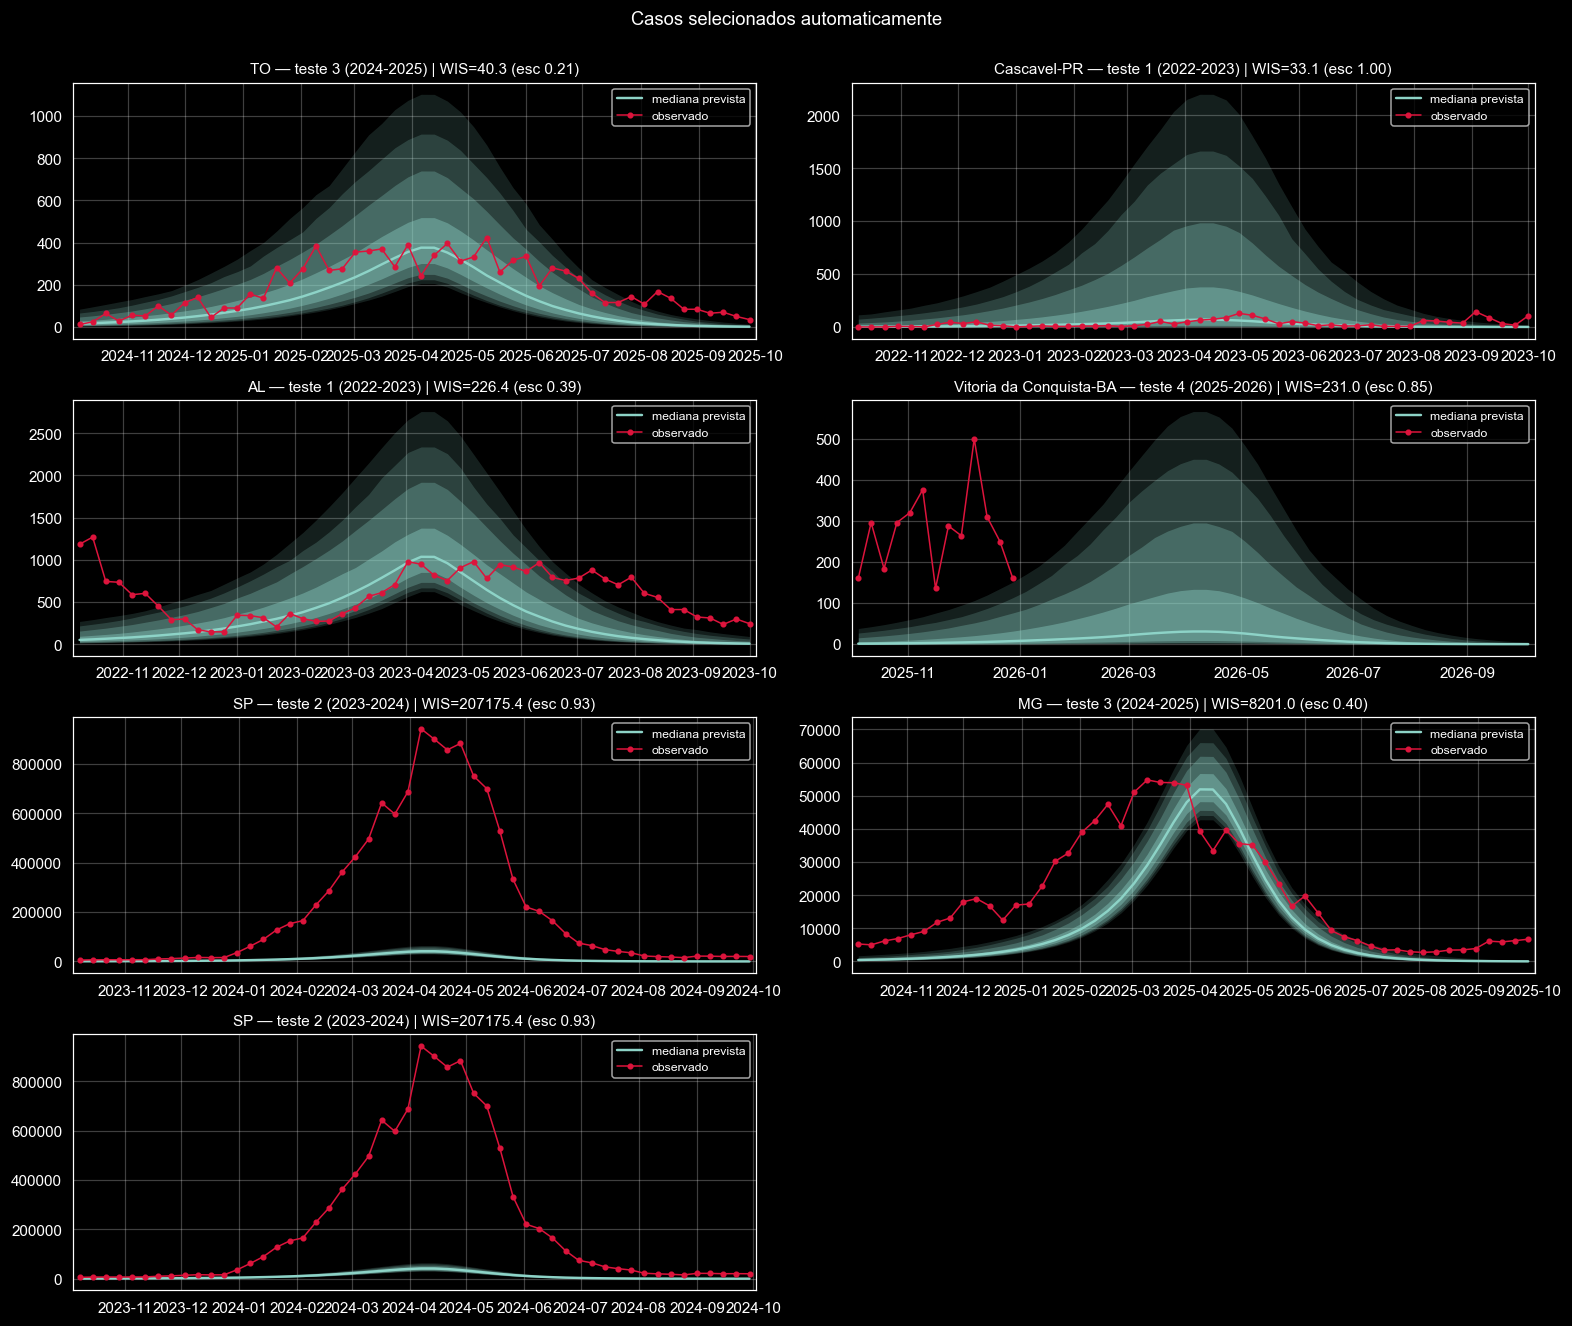

In [14]:
def pick(df, col, how="min"):
    d = df.dropna(subset=[col])
    r = d.loc[d[col].idxmin()] if how=="min" else d.loc[d[col].idxmax()]
    return (r["level"], r["unit"], int(r["test"]), r["name"])

cases = {}
cases["melhor WIS escalado"]      = pick(M, "wis_scaled", "min")
cases["pior WIS escalado"]        = pick(M, "wis_scaled", "max")
M["abs_peak_err"] = M["peak_week_err"].abs()
cases["maior erro de pico"]       = pick(M, "abs_peak_err", "max")
cases["pior cobertura 95%"]       = pick(M, "cov_95", "min")
cases["maior sub-previsão"]       = pick(M, "under", "max")
cases["maior super-previsão"]     = pick(M, "over", "max")
cases["maior surto (total obs)"]  = pick(M, "total_obs", "max")

for label, (lv,un,ts,nm) in cases.items():
    print(f"- {label:24s}: {lv:5s} {nm} (teste {ts})")

items = [ (lv,un,ts) for (lv,un,ts,nm) in cases.values() ]
fan_grid(items, ncols=2, title="Casos selecionados automaticamente")


## 9. Exportar métricas

Salva a tabela completa (uma linha por unidade‑teste) para uso posterior / relatório.

In [15]:
out_csv = os.path.join(REPORTS, "eval_metrics.csv")
M.round(4).to_csv(out_csv, index=False)
print("salvo:", out_csv)
# resumo executivo
print("\nWIS escalado médio por trilha:")
print(M.groupby("level")["wis_scaled"].mean().round(3).to_string())
print("\nCobertura média (deveria ~ nominal):")
print(M[[f'cov_{p}' for p in [50,80,90,95]]].mean().round(3).to_string())


salvo: ../reports\eval_metrics.csv

WIS escalado médio por trilha:
level
city     0.629
state    0.613

Cobertura média (deveria ~ nominal):
cov_50    0.080
cov_80    0.187
cov_90    0.289
cov_95    0.360


### Como ler estes resultados (resumo)

- **WIS escalado** compara unidades: menor = melhor. Use o *heatmap* e o *ranking* para ver
  quais UFs/cidades e quais temporadas puxam o erro.
- **Decomposição**: muita **dispersão** → intervalos largos; **sub** ≫ **super** → o modelo
  subestima (comum no estadual se municípios sem ajuste ficaram de fora da soma).
- **Cobertura < nominal** → intervalos estreitos demais; é o sintoma esperado quando a
  incerteza é propagada de forma independente (parâmetros/municípios). Uma **calibração por
  resíduos** das temporadas de validação tende a corrigir o WIS.
- **Erro vs magnitude** e **erro por semana** mostram se o problema é nos surtos grandes ou
  perto do pico. **Timing do pico** separa erro de *quando* vs. de *quanto*.

**Ressalvas:** a 2025‑26 é parcial (semanas futuras sem observado); o total estadual
previsto exclui municípios sem ajuste do episcanner (o observado, não). Este WIS local usa
a série `casos` do parquet; o placar oficial usa os dados da plataforma e pode diferir
ligeiramente.